# Intro to Linear Systems

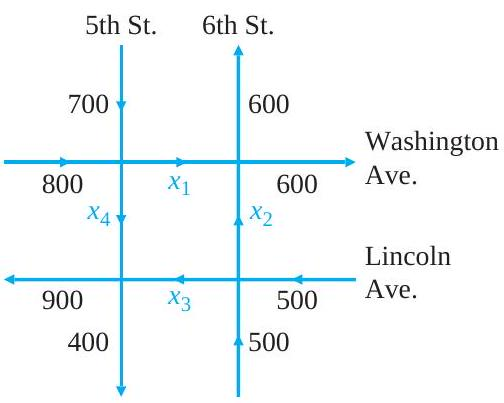

# *Outline for today*

-   Linear systems: what they are + a few examples
-   Gauss-Jordan elimination (as a general-purpose method)
-   What can go wrong with roundoff
-   A simple fix: (partial) pivoting
-   Ill-conditioning: sometimes the *problem* is the issue
-   Polynomial interpolation as an example

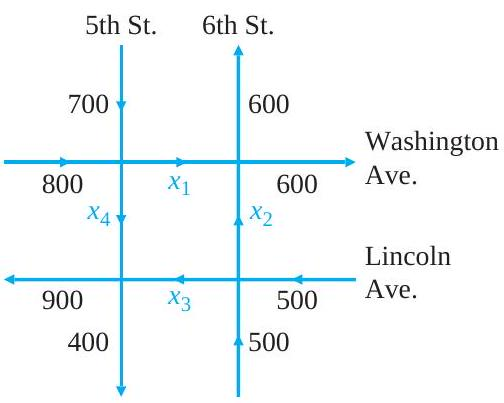

# *Linear systems*

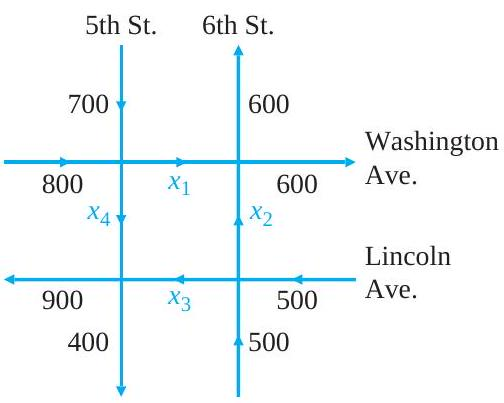

## *Application number one: solving linear systems*

-   The first big thing we will use linear algebra for is solving
    *systems of linear equations*.
-   Hope to convince you that this is **useful** but not entirely
    **straightforward**!

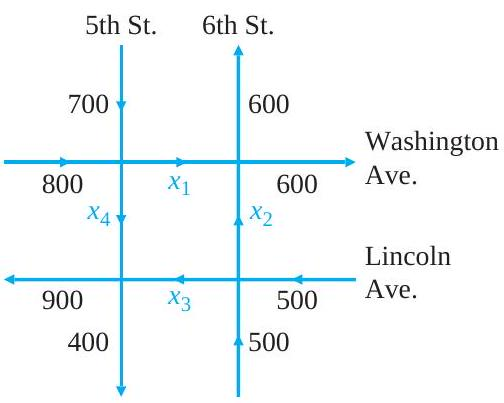

## *Linear equations*

We all know what “linear” means: straight!

. . .

-   A linear equation of one variable is of the form $ax + b = 0$.
    -   Solution: A single point on the number line: $x = -\frac{b}{a}$
-   A linear equation of two variables is of the form $ax + by + c = 0$.
    -   Solution: any pair of values $(x, y)$ that satisfies the
        equation. These form a straight line in the plane.
-   A linear equation of three variables is of the form
    $ax + by + cz + d = 0$.
    -   Solution: any triple of values $(x, y, z)$ that satisfies the
        equation. These form a plane in three-dimensional space.
-   In general, a linear equation of $n$ variables is of the form
    $a_1 x_1 + a_2 x_2 + \dots + a_n x_n + b = 0$.

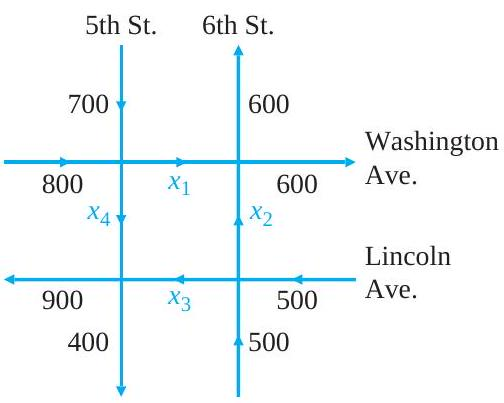

## *Linear systems*

-   Linear system: a collection of linear equations involving the same
    variables $x_1, x_2, \dots, x_n$.
-   Each equation has its own set of coefficients $a_{ij}$ and its own
    right-hand side $b_i$. So the 3rd equation might look like
    $a_{31} x_1 + a_{32} x_2 + \dots + a_{3n} x_n = b_3$.

. . .

When we put them all together, we get a linear system:

$$
\begin{cases}
a_{11} x_1 + a_{12} x_2 +\dots + a_{1n} x_n = b_1 \\
a_{21} x_1 + a_{22} x_2  + \dots + a_{2n} x_n = b_2 \\ 
\vdots\\
a_{m1} x_1 + a_{m2} x_2 + \dots + a_{mn} x_n = b_m,
\end{cases}
$$

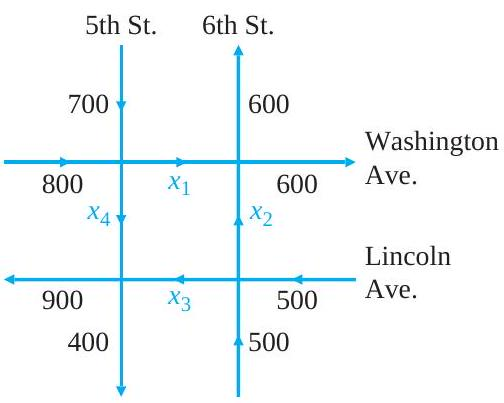

## *Why do we care about systems of equations?*

We use equations to represent constraints (physics, data, budgets,
flows, etc.) When there are multiple constraints, we get a system of
equations.

. . .

Examples:

. . .

Of course, many equations we can think of won’t be linear… But many
things are!

-   Once you write a model down, it often becomes (Ax=b)
-   Then the question is: can we solve it **reliably**?

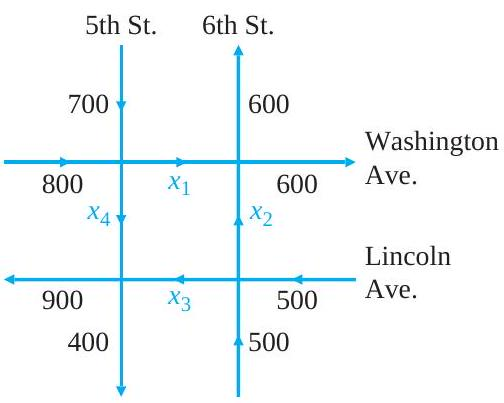

# *Examples of linear systems (we aren’t going to solve them yet!)*

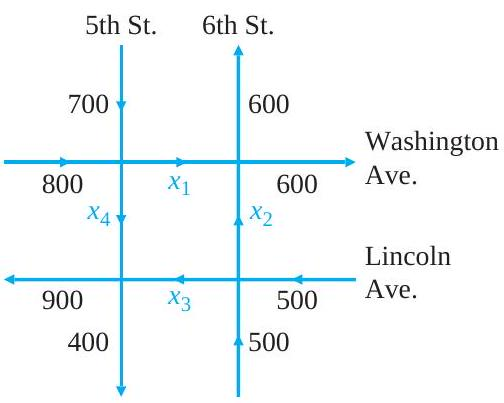

## *Example 1: railroad cars*

A chemical manufacturer wants to lease a fleet of 24 railroad tank cars
with a combined carrying capacity of 520,000 gallons.

-   Tank cars with three different carrying capacities are available:
    -   8,000 gallons
    -   16,000 gallons
    -   24,000 gallons.
-   How many of each type of tank car should be leased?

. . .

Will we have a single solution?

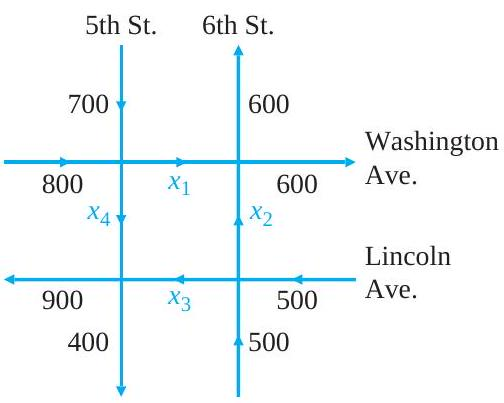

## *Example 2: traffic flow.*

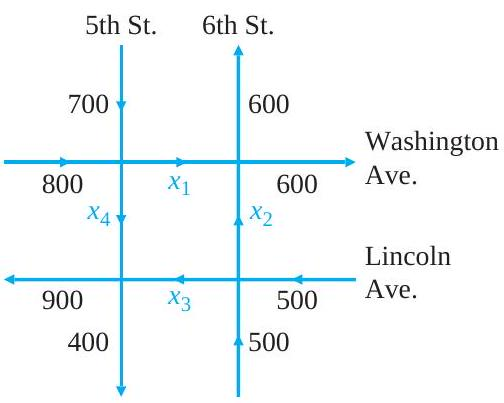

-   Numbers = \# of vehicles/hr that enter and leave on that street.
-   $x_{1}, x_{2}, x_{3}$, and $x_{4}$: flow of traffic between the four
    intersections.

-   Number of vehicles entering each intersection should always equal
    the number leaving. E.g.:
    -   1,500 vehicles enter the intersection of 5th Street and
        Washington Avenue each hour
    -   $x_{1}+x_{4}$ vehicles leave this intersection
    -   $\rightarrow$ $x_{1}+x_{4}=1,500$
-   Find the traffic flow at each of the other three intersections.
-   What is the \# of vehicles that travel from Washington Avenue to
    Lincoln Avenue on 5th Street?


## *Example: US population*

-   The U.S. population was approximately 75 million in 1900, 150
    million in 1950, and 275 million in 2000.
-   Find a quadratic equation whose graph passes through the points
    $(0,75)$, $(50,150)$, $(100,275)$

. . .

Wait, what? How is this a **linear** system?

. . .

There are three years that our graph needs to pass through: 1900, 1950,
and 2000. We can write these as $t_1 = 0$, $t_2 = 50$, and $t_3 = 100$.

We can write the population as $y_1 = 75$, $y_2 = 150$, and $y_3 = 275$.

. . .

We are asked to find a *quadratic equation*, which means it’s of the
form $y = ax^2 + bx + c$. We need to find the values of $a$, $b$, and
$c$ so that the equation passes through our three points.

For the first point, we have $a t_1^2 + b t_1 + c = y_1$. Since $t_1$=0,
this becomes $a 0^2 + b 0 + c = 75$.

## 

If we do this for the other two points, we get the system:

$$
\begin{cases}
a t_1^2 + b t_1 + c = y_1 \\
a t_2^2 + b t_2 + c = y_2 \\
a t_3^2 + b t_3 + c = y_3
\end{cases}
$$

. . .

Is this linear?

. . .

Yes, it is linear in $a$, $b$, and $c$, because none of them is raised
to a power other than 1.

## 

The terms that are squared are just coefficients. We can even calculate
them: $t_2^2 = 2500$, for instance. Then we can rewrite the system as:

$$
\begin{cases}
0 a + b 0 + c = 75 \\
2500 a + 50 b + c = 150 \\
10000 a + 100 b + c = 275
\end{cases}
$$

. . .

We see that we now have a standard system of linear equations.

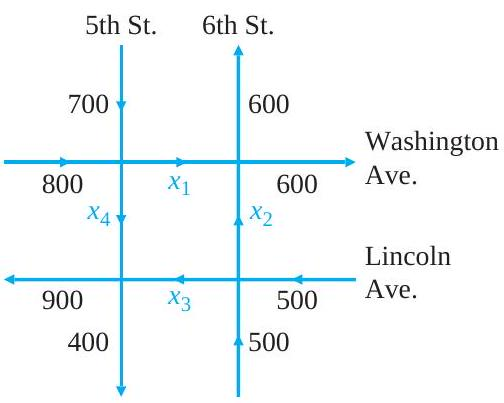

# *Solving linear systems – bring in the linear algebra!*

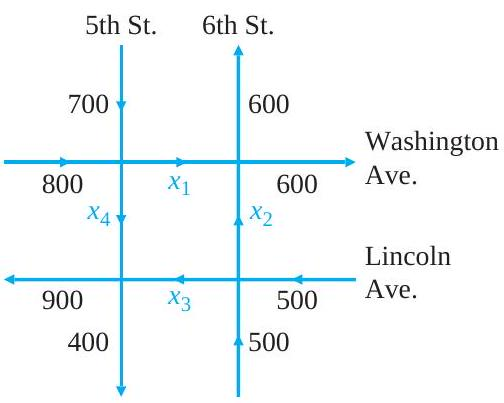

## *Why not just solve by hand?*

-   We want procedures that work for many variables, not just (2) or (3)
-   We care about accuracy, but also stability: do small errors get
    amplified?
-   We care about efficiency and reusability (especially when solving
    (Ax=b) for lots of different (b)’s)

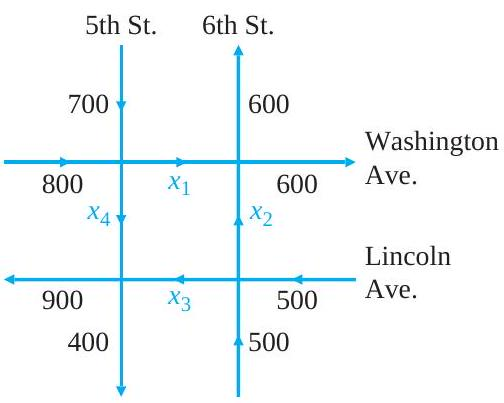

## *Goals for algorithms*

An algorithm should be:

-   feasible
-   accurate
    -   stable
-   efficient
    -   reusable computations

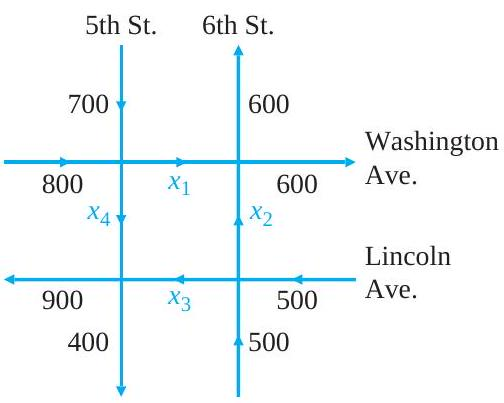

## *Example: very simple linear system*

We’ll get started with an example that is easy enough to solve by hand.
We’ll pay attention to what we do, and why.

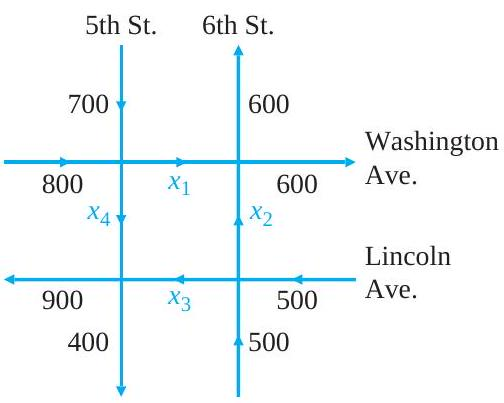

## *Augmented matrix*

It was a little hard to keep track of the variables just there.

(Not really! It shouldn’t have been! But it’s late when I’m writing
this, and my brain doesn’t work so well, I need something easier…)

. . .

Make an *augmented matrix* to represent the problem.

Rules for an augmented matrix: - The numbers in the first column are the
coefficients of the first variable, for each equation. - The numbers in
the second column are the coefficients of the second variable, for each
equation. And so on. - The numbers in the last column are the right-hand
sides of the equations.

## 

Remember, our two equations were:

. . .

So as an augmented matrix, they become:

$$
\begin{aligned}
& x \quad y=r . h . s . \\
& {\left[\begin{array}{rrr}
2 & -1 & 1 \\
4 & 4 & 20
\end{array}\right]}
\end{aligned}
$$

. . .

Our goal: manipulate the augmented matrix to solve the problem.

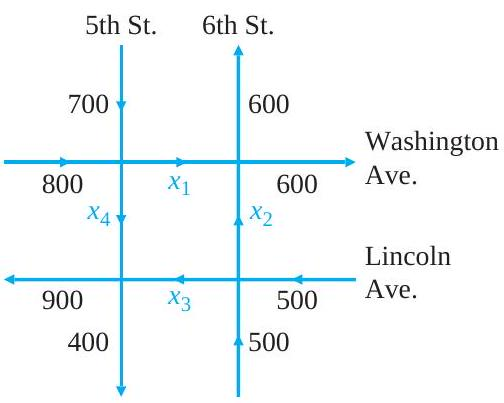

## *What things can we do while we are solving the problem?*

We are going to change around the numbers in our matrix *without
changing the solution*.

. . .

What does that mean? It means that we will manipulate the matrix so it
represents *different* systems of equations that have the **same
solution**.

. . .

For example, these two systems have the same solution:

. . .

We have simply swapped the order of the equations. They still have the
same solution.

How does this change the matrix? It swaps the first and second rows.

$$\begin{aligned}
& x \quad y=r . h . s . \\
& {\left[\begin{array}{rrr}
4 & 4 & 20 \\
2 & -1 & 1
\end{array}\right]}
\end{aligned}
$$

. . .

Swapping the rows of the matrix is equivalent to swapping the order of
the equations, and **it does not change the solution**.

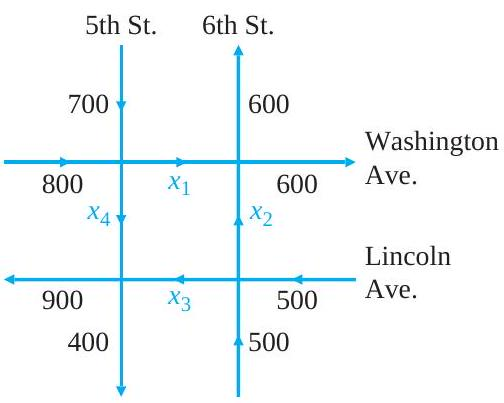

## *Multiplying a row by a constant*

We can also multiply one of our equations by a constant. For example, if
we multiply the second equation by 2, we get:

. . .

This has the same solution as the original system.

. . .

How does this change the matrix? It multiplies the second row by 2.

$$\begin{aligned}
& x \quad y=r . h . s . \\
& {\left[\begin{array}{rrr}
2 & -1 & 1 \\
8 & 8 & 40
\end{array}\right]}
\end{aligned}
$$

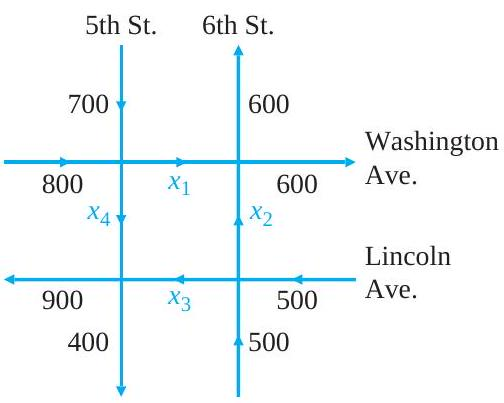

## *Adding a multiple of one row to another*

We did this when we were solving the problem by hand. We subtracted two
times the first row from the second row.

How does this change the matrix? It adds -2 times the first row to the
second row.

$$\begin{aligned}
& x \quad y=r . h . s . \\
& {\left[\begin{array}{rrr}
2 & -1 & 1 \\
0 & 6 & 18
\end{array}\right]}
\end{aligned}
$$

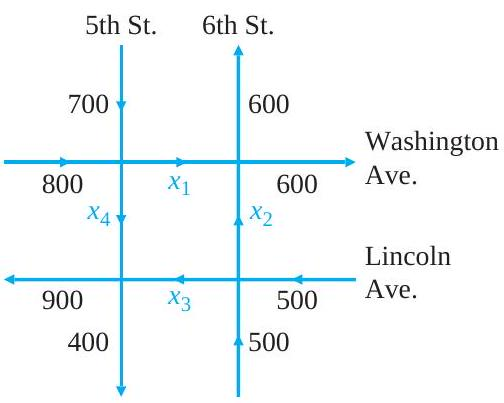

## *Elementary Matrix Operations*

When we do these on augmented matrices, the solutions are unchanged…

1.  $E_{i j}$ : **Swap**: Switch the $i$th and $j$ th rows of the
    matrix.
2.  $E_{i}(c)$ : **Scale**: Multiply the $i$th row by the nonzero
    constant $c$.
3.  $E_{i j}(d)$ : **Add**: Add $d$ times the $j$th row to the $i$th
    row.

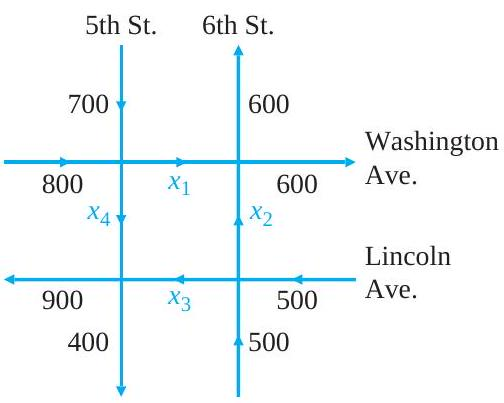

## *Our strategy*

We are going to use a sequence of elementary row operations to transform
our augmented matrix into a form where we will be able to read off the
solution.

. . .

This form is called **reduced row echelon form**.

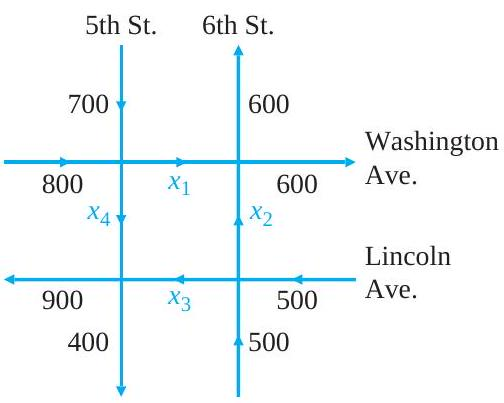

## *Reduced row echelon form*

Here is an example of an augmented matrix in reduced row echelon form:

$$
\begin{aligned}
& x \quad y=r . h . s . \\
& {\left[\begin{array}{rrr}
1 & 4 & 2 \\
0 & 1 & 3
\end{array}\right]}
\end{aligned}
$$

. . .

It corresponds to the following system of equations:

. . .

See how easy that is to solve? We can just read from the bottom up:
$y=3$, and then $x + 4(3) = 2$, so $x = 2 - 12 = -10$.

. . .

Any time we can get an augmented matrix into reduced row echelon form,
it will be this easy to solve.

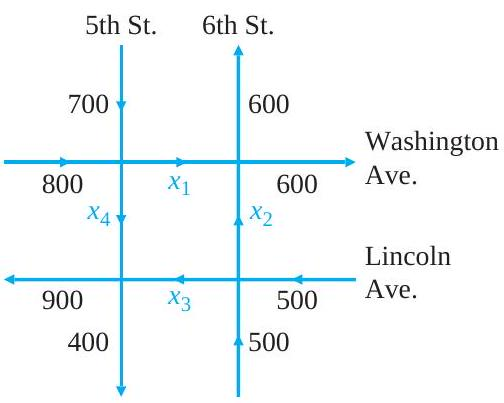

## *Rules for Reduced Row Echelon Form*

Every matrix can be reduced by a sequence of elementary row operations
to one and only one reduced row echelon form:

-   Nonzero rows of $R$ precede the zero rows.
-   Column numbers of the leading entries of the nonzero rows, say rows
    $1,2, \ldots, r$, form an increasing sequence of numbers
    $c_{1}<c_{2}<\cdots<c_{r}$.
-   Each leading entry is a 1.
-   Each leading entry has only zeros above it.

. . .

We just need to know which row operations to do, and in what order. Then
we can solve any linear system!

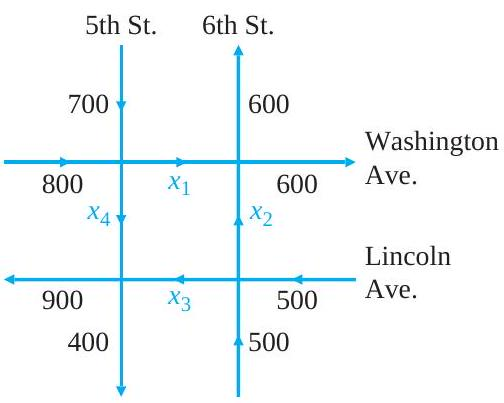

# *An algorithm for getting an augmented matrix into reduced row echelon form*

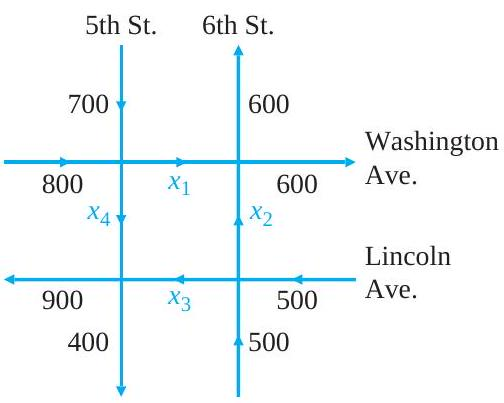

## *Gauss-Jordan elimination*

1.  Swap rows to get non-zero number in row 1, column 1
2.  Get a **1** in the row 1, column 1.
3.  Make all other entries in column 1 **0**.
4.  Swap rows to get non-zero number in row 2, column 2. Make this entry
    **1**. Make all other entries in column 2 **0**.
5.  Repeat step 4 for row 3, column 3. Continue moving along the main
    diagonal until you reach the last row, or until the number is zero.

. . .

Vocabulary: process of getting a 1 in a location, and then making all
other entries zeros in that column, is **pivoting**.

The number that is made a 1 is called the pivot element, and the row
that contains the pivot element is called the **pivot row**.

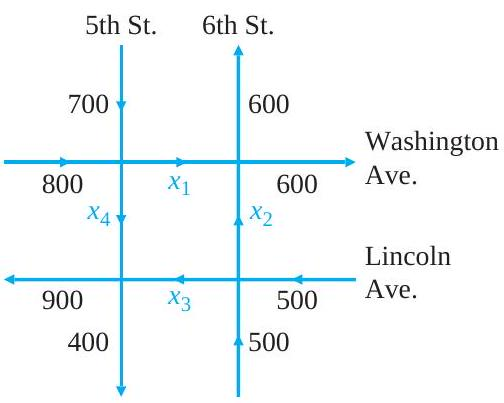

## *G-J Elimination for our toy system*

$$
\left[\begin{array}{rrr}
4 & 4 & 20 \\
2 & -1 & 1
\end{array}\right] \overrightarrow{E_{1}(\frac{1}{4}}\left[\begin{array}{lll}
1 & 1 & 5 \\
2 & -1 & 1
\end{array}\right] \overrightarrow{E_{12}(-2)}\left[\begin{array}{lll}
1 & 1 & 5 \\
0 & -3 & -9
\end{array}\right]
$$

and then…

. . .

$$
\left[\begin{array}{rrr}
1 & 1 & 5 \\
0 & -3 & -9
\end{array}\right] \overrightarrow{E_{2}(-1 / 3)}\left[\begin{array}{lll}
1 & 1 & 5 \\
0 & 1 & 3
\end{array}\right] \overrightarrow{E_{12}(-1)}\left[\begin{array}{lll}
1 & 0 & 2 \\
0 & 1 & 3
\end{array}\right] .
$$

. . .

Writing this back as a linear system, we have:

$$
\begin{aligned}
2 x-y &= 1 \\
4 x+4 y &= 20
\end{aligned}
\Longrightarrow
\begin{aligned}
1 \cdot x+0 \cdot y &= 2 \\
0 \cdot x+1 \cdot y &= 3
\end{aligned}
\Longrightarrow
\begin{aligned}
x &= 2 \\
y &= 3
\end{aligned}
$$

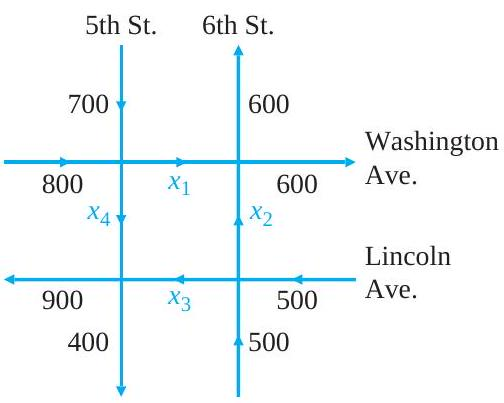

## *Now you try: birds in a tree*

There are 2 trees in a garden (tree “A” and “B”) and in both trees are
some birds.

The birds of tree A say to the birds of tree B that if one of you comes
to our tree, then our population will be double yours.

Then the birds of tree B tell the birds of tree A that if one of you
comes here, then our population will be equal to yours.

How many birds in each tree?

(Solve by making an augmented matrix and doing G-J elimination.)

https://www.mathsisfun.com/puzzles/birds-in-trees.html

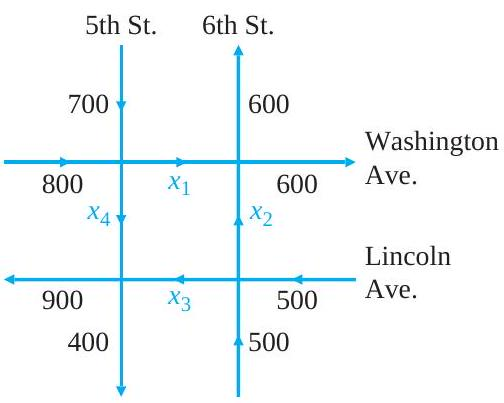

## *Example: Mining*

Meyer Ch 1.5

A mine produces *silica*, *iron*, and *gold*

Needs **Money** (in \$\$), **operating time** (in hours), and **labor**
(in person-hours).

-   1 pound of silica needs: \$.0055, . 0011 hours of operating time,
    and .0093 hours of labor.

-   1 pound of iron needs: \$.095, . 01 operating hours, and .025 labor
    hours.

-   1 pound of gold needs: \$ 960, 112 operating hours, and 560 labor
    hours.

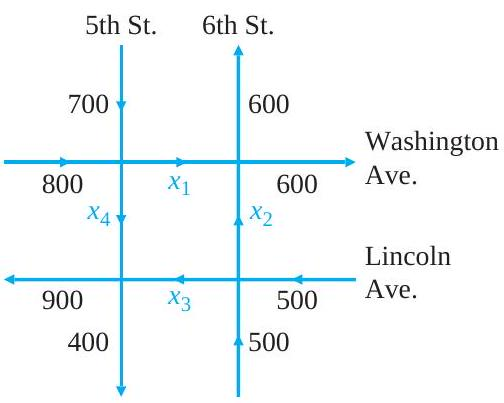

## *Mining example: from story () linear system*

Suppose that during 600 hours of operation, exactly \$ 5000 and 3000
labor-hours are used.

How much silica ($x$), iron ($y$), and gold ($z$) were produced?

. . .

Set up the linear system whose solution will yield the values for
$x, y$, and $z$.

. . .

$$
\begin{aligned}
.0055 x + .095 y + 960 z &=  5000 \quad \text{(dollars)}\\
.0011 x + .01 y + 112 z &= 600 \quad \text{(operating hours)}\\
.0093 x + .025 y + 560 z &= 3000\quad \text{(labor hours)}
\end{aligned}
$$

. . .

Make the *augmented matrix*:

$$
\left[\begin{array}{@{}ccc|c@{}}
.0055 & .095 & 960 & 5000 \\
 .0011 & .01  & 112 & 600 \\
 .0093 & .025 & 560 & 3000
\end{array}\right]
$$

## 

We can solve this using Gauss-Jordan elimination.

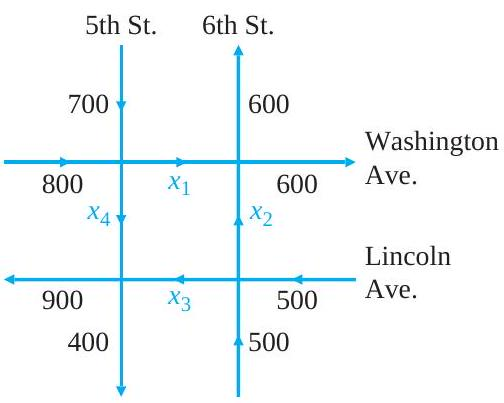

In [1]:
from sympy.matrices import Matrix, eye, zeros, ones, diag, GramSchmidt
from sympy.core.numbers import Number
from sympy import print_latex, latex,N
def round_expr(expr, num_digits):
    return expr.xreplace({n : round(n, num_digits) for n in expr.atoms(Number)})

In [2]:
# Do the Gauss-Jordan elimination
M=Matrix([[.0055,.095,960,5000],[.0011,.01,112,600],[.0093,.025,560,3000]])
round_level = 2;
M2=N(M.elementary_row_op('n->n+km', row=1,row2=0, k=-(M[1,0]/M[0,0])),round_level)
M3=N(M2.elementary_row_op('n->n+km', row=2,row2=0, k=-(M2[2,0]/M2[0,0])),round_level)
M4=N(M3.elementary_row_op('n->n+km', row=2,row2=1, k=-(M3[2,1]/M3[1,1])),round_level)

In [3]:
from IPython.display import Markdown
def pp(x):
  print("$"+latex(x)+"$")
def ppd(x): 
  print("$$"+latex(x)+"$$")
def mm(x):
  Markdown(latex(x))

## *Getting into row echelon form, rounding after 3 digits*

$$\left[\begin{matrix}0.0055 & 0.095 & 960 & 5000\\0.0011 & 0.01 & 112 & 600\\0.0093 & 0.025 & 560 & 3000\end{matrix}\right] \overrightarrow{E_{12}(\frac{-1}{5})} \left[\begin{matrix}0.0055 & 0.095 & 9.6 \cdot 10^{2} & 5.0 \cdot 10^{3}\\0 & -0.009 & -80.0 & -4.0 \cdot 10^{2}\\0.0093 & 0.025 & 5.6 \cdot 10^{2} & 3.0 \cdot 10^{3}\end{matrix}\right]$$

$$\overrightarrow{E_{13}(\frac{93}{55})} \left[\begin{matrix}0.0055 & 0.095 & 9.6 \cdot 10^{2} & 5.0 \cdot 10^{3}\\0 & -0.009 & -80.0 & -4.0 \cdot 10^{2}\\0 & -0.14 & -1.1 \cdot 10^{3} & -5.4 \cdot 10^{3}\end{matrix}\right]$$

$$\overrightarrow{E_{23}(\frac{-14}{.9})} \left[\begin{matrix}0.0055 & 0.095 & 9.6 \cdot 10^{2} & 5.0 \cdot 10^{3}\\0 & -0.009 & -80.0 & -4.0 \cdot 10^{2}\\0 & 0 & 1.4 \cdot 10^{2} & 5.7 \cdot 10^{2}\end{matrix}\right]$$

## *Mining example: solve (and then compare to exact)*

In [4]:
soln=M4[0:3,0:3].solve(rhs=M4[:,3])

This has solutions
$\left[\begin{matrix}5.7 \cdot 10^{4}\\8.9 \cdot 10^{3}\\4.0\end{matrix}\right]$.

. . .

How do these compare to the exact solutions? These are

In [5]:
M[0:3,0:3].solve(rhs=M[:,3])

## *Doing it again, rounding after 15 digits*

In [6]:
# Do the Gauss-Jordan elimination
M=Matrix([[.0055,.095,960,5000],[.0011,.01,112,600],[.0093,.025,560,3000]])
round_level = 15;
ml = latex(M)
M2=N(M.elementary_row_op('n->n+km', row=1,row2=0, k=-(M[1,0]/M[0,0])),round_level)
M3=N(M2.elementary_row_op('n->n+km', row=2,row2=0, k=-(M2[2,0]/M2[0,0])),round_level)
M4=N(M3.elementary_row_op('n->n+km', row=2,row2=1, k=-(M3[2,1]/M3[1,1])),round_level)

$\left[\begin{matrix}0.0055 & 0.095 & 960 & 5000\\0.0011 & 0.01 & 112 & 600\\0.0093 & 0.025 & 560 & 3000\end{matrix}\right] \rightarrow \left[\begin{matrix}0.0055 & 0.095 & 960.0 & 5000.0\\0 & -0.009 & -80.0 & -400.0\\0.0093 & 0.025 & 560.0 & 3000.0\end{matrix}\right]$

$\rightarrow \left[\begin{matrix}0.0055 & 0.095 & 960.0 & 5000.0\\0 & -0.009 & -80.0 & -400.0\\0 & -0.135636363636364 & -1063.27272727273 & -5454.54545454545\end{matrix}\right] \rightarrow \left[\begin{matrix}0.0055 & 0.095 & 960.0 & 5000.0\\0 & -0.009 & -80.0 & -400.0\\0 & 0 & 142.383838383838 & 573.737373737372\end{matrix}\right]$

In [7]:
soln2=M4[0:3,0:3].solve(rhs=M4[:,3])

This has solutions
$\left[\begin{matrix}56753.6889897845\\8626.56072644727\\4.02951191827468\end{matrix}\right]$.

Reminder, the exact solution was:

In [8]:
M[0:3,0:3].solve(rhs=M[:,3])

## *Takeaway (mining example)*

-   Gauss–Jordan gives the correct answer in **exact arithmetic**.
-   In floating-point arithmetic, intermediate rounding can change the
    computed result.
-   Next: we make “accuracy vs stability” concrete with roundoff
    examples and pivoting.

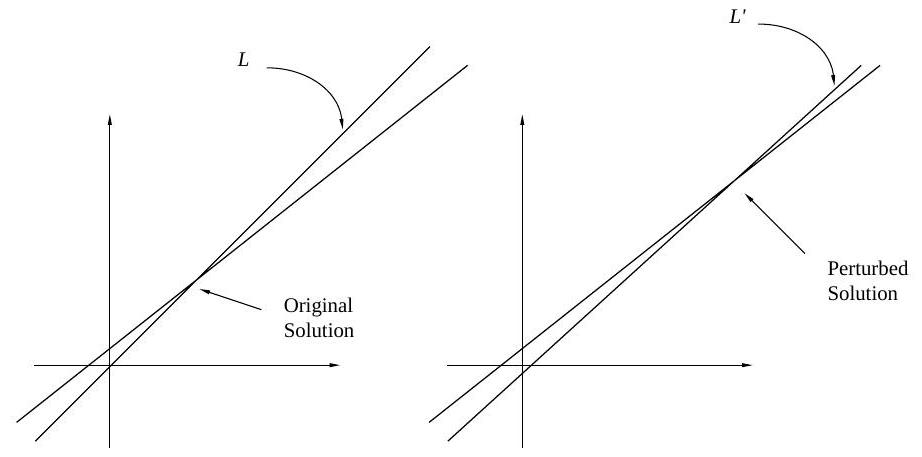

# *Comparing the G-J algorithm with our goals*

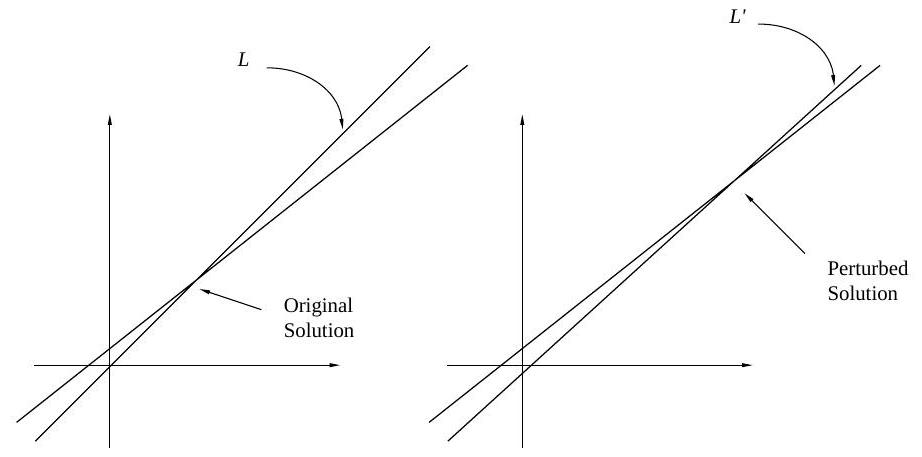

## *Reminder of goals*

An algorithm should be:

-   feasible
-   accurate
    -   stable
-   efficient
    -   reusable computations

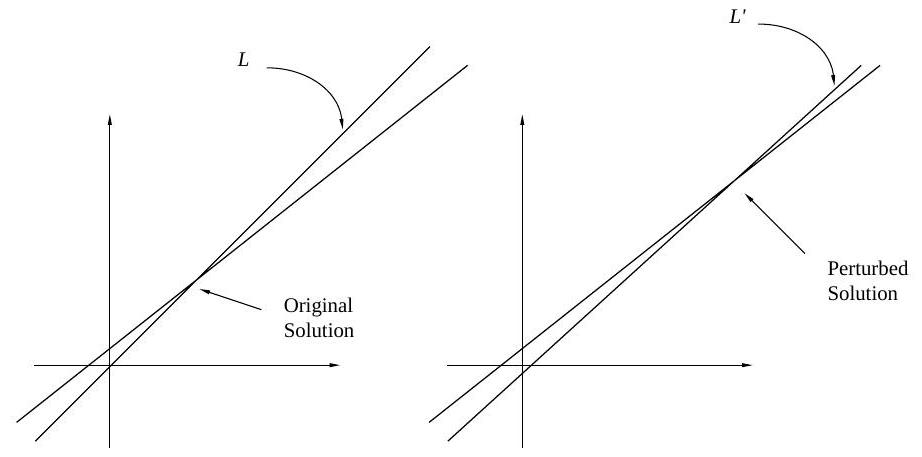

# *Roundoff errors*

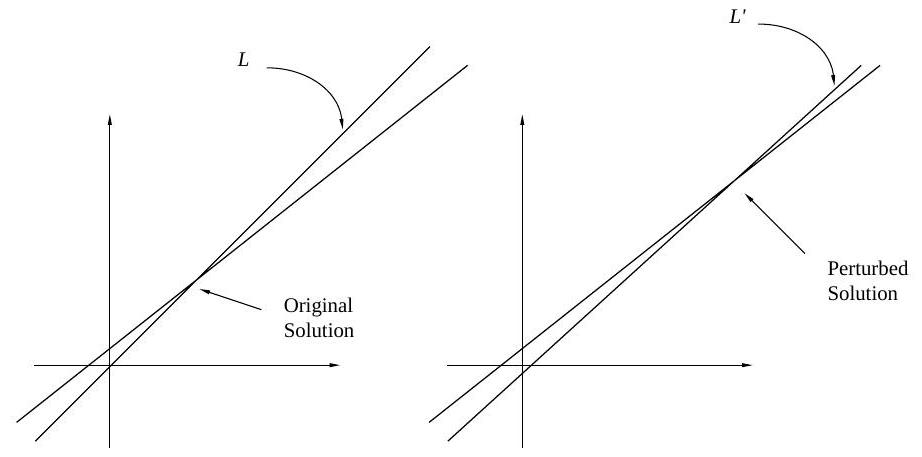

## *Roundoff errors with G-J elimination*

Try this on your calculator. What do you get?

$$
\left(\left(\frac{2}{3}+100\right)-100\right)-\frac{2}{3}
$$

. . .

Should this be (0)?

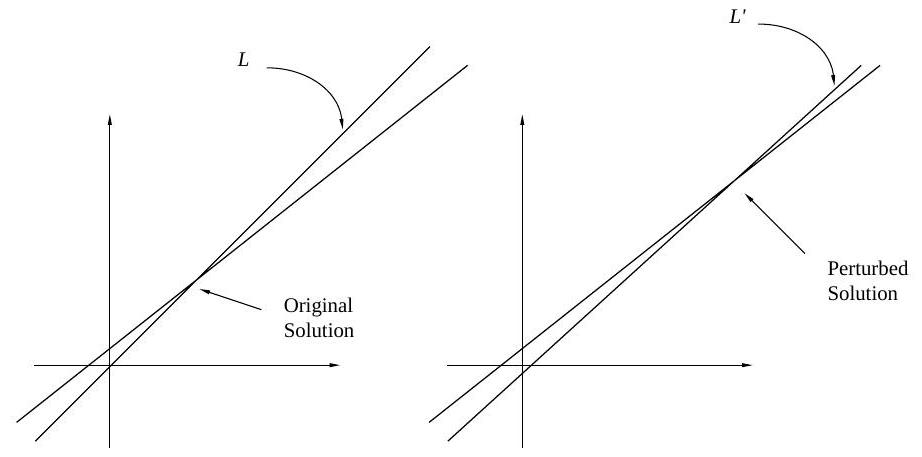

## *Roundoff example: tiny () and loss of significance*

-   Let $\epsilon$ be a number so small that our calculator yields
    $1+\epsilon=1$.

-   With this calculator,
    $1+1 / \epsilon=(\epsilon+1) / \epsilon=1 / \epsilon$

-   Want to solve the linear system

-

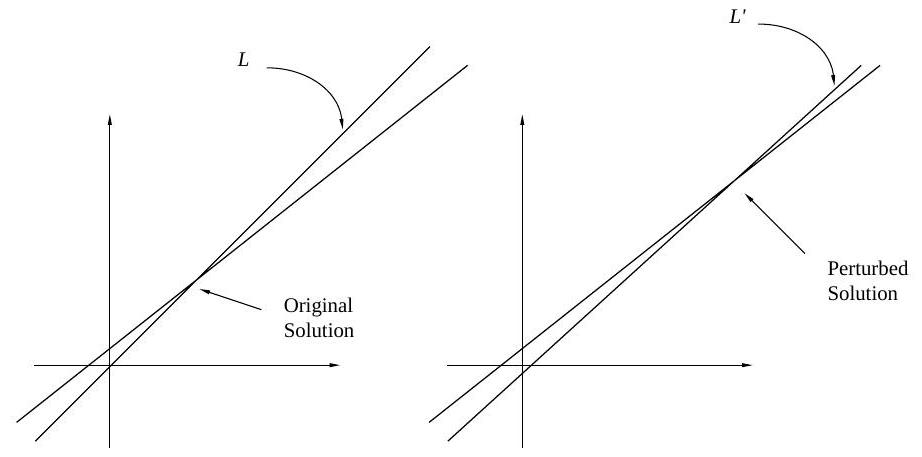

## *Roundoff errors with G-J elimination*

With our calculator,

$$
    \left[\begin{array}{rrr}
    \epsilon & 1 & 1 \\
    1 & -1 & 0
    \end{array}\right] \overrightarrow{E_{21}\left(-\frac{1}{\epsilon}\right)}\left[\begin{array}{ccc}
    \epsilon & 1 & 1 \\
    0 & \frac{1}{\epsilon} & -\frac{1}{\epsilon}
    \end{array}\right] \overrightarrow{E_{2}(\epsilon)}\left[\begin{array}{ccc}
    \epsilon & 1 & 1 \\
    0 & 1 & 1
    \end{array}\right] \\ \overrightarrow{E_{12}(-1)}\left[\begin{array}{ccc}
    \epsilon & 0 & 0 \\
    0 & 1 & 1
    \end{array}\right]  \overrightarrow{E_{1}\left(\frac{1}{\epsilon}\right)}\left[\begin{array}{lll}
    1 & 0 & 0 \\
    0 & 1 & 1
    \end{array}\right] .
$$

. . .

Calculated solution: $x_{1}=0, x_{2}=1$

Correct answer should be

$$ x_{1}=x_{2}=\frac{1}{1+\epsilon}=0.999999099999990 \ldots$$

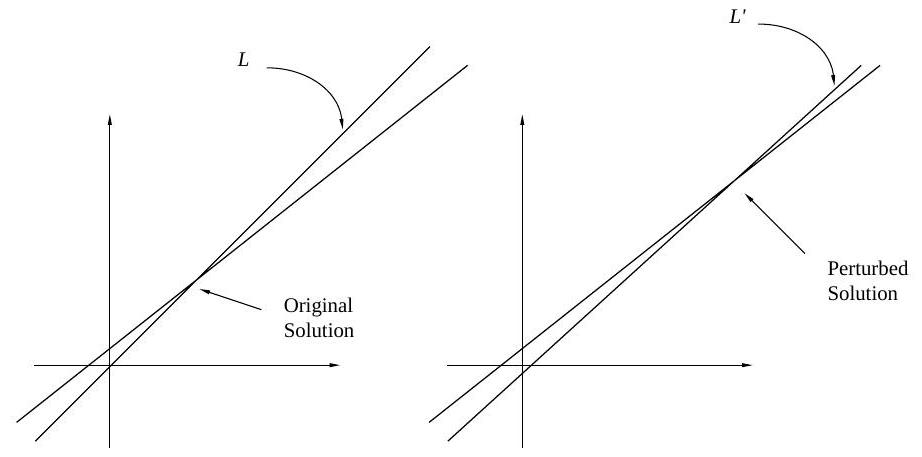

## *Sensitivity to small changes*

Problem arose because we took a computational step where we added two
numbers of very different scale, essentially losing the smaller number.

Led to a big changes in output!

There is no general cure for these difficulties…

Want to be *aware* of them, know when we are doing computations that
might be susceptible.

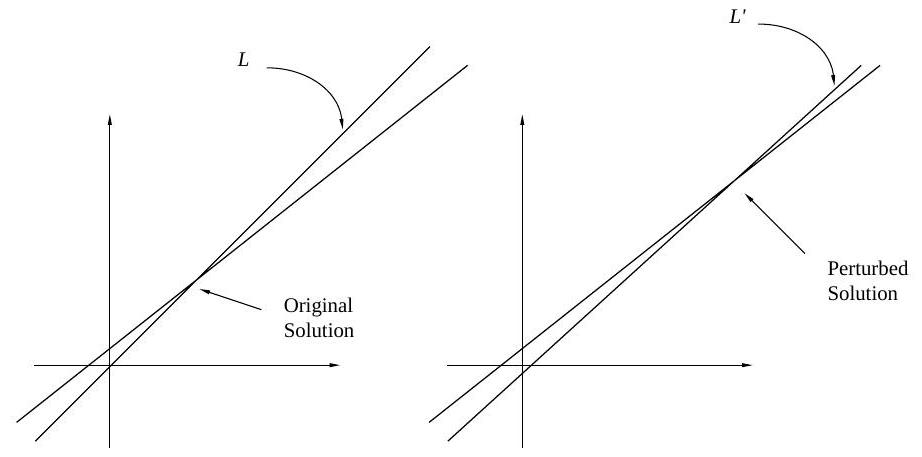

## *Partial pivoting*

We can improve performance of G-J by introducing a new step into the
algorithm:

1.  Find the entry in the left column <span style="color:red;">with the
    largest absolute value</span>. This entry is called the pivot.
    Perform row interchange (if necessary), so that *the pivot* is in
    the first row.

2.  Use a row operation to get a 1 as the entry in the first row and
    first column.

3.  Use row operations to make all other entries as zeros in column one.

4.  Interchange rows if necessary to obtain a nonzero number
    <span style="color:red;">with the largest absolute value</span> in
    the second row, second column. Use a row operation to make this
    entry 1. Use row operations to make all other entries as zeros in
    column two.

5.  Repeat step 4 for row 3, column 3. Continue moving along the main
    diagonal until you reach the last row, or until the number is zero.

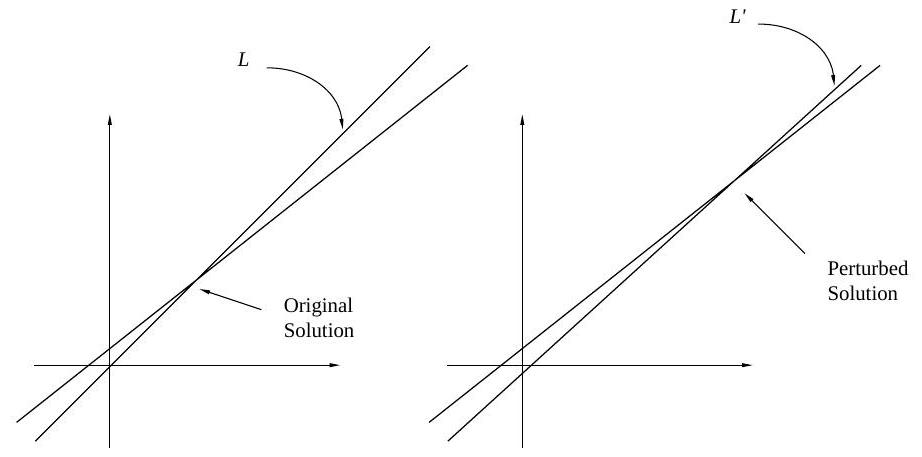

## *Using partial pivoting in our example*

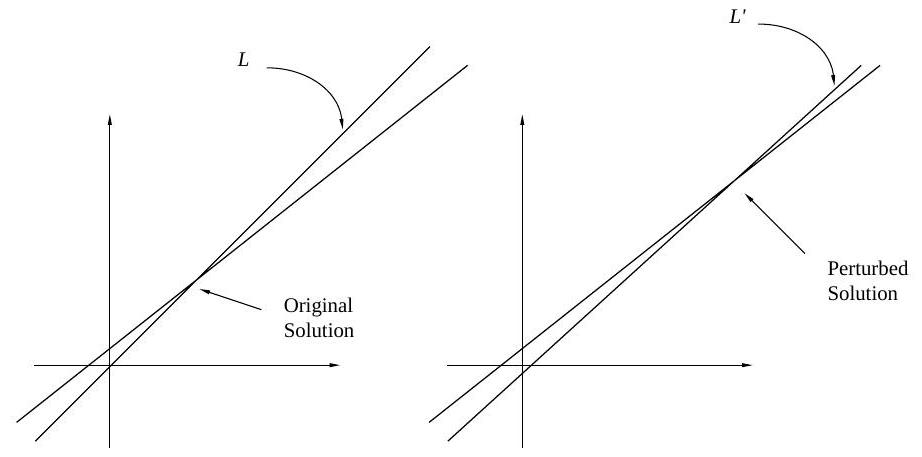

# *Ill-conditioned linear systems*

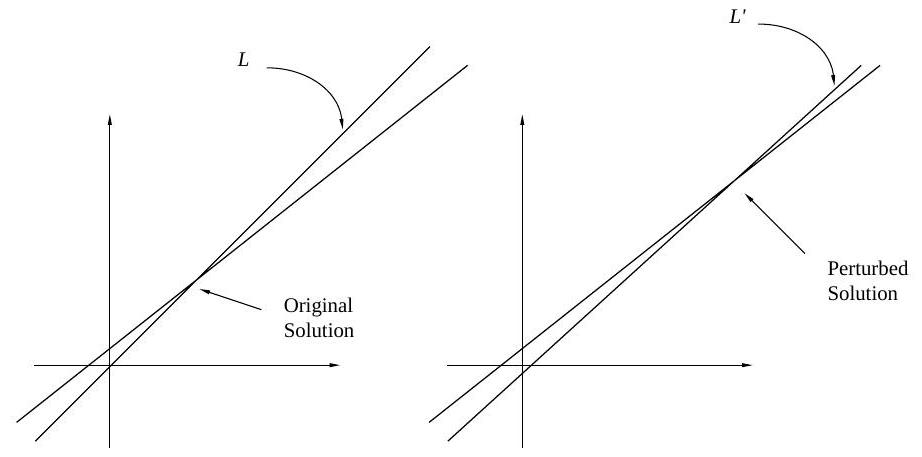

## *Ill-conditioned linear systems*

A system of linear equations is said to be **ill-conditioned** when some
small perturbation in the system (in the $b$s) can produce relatively
large changes in the exact solution (in the $x$’s). Otherwise, the
system is said to be **well-conditioned**.

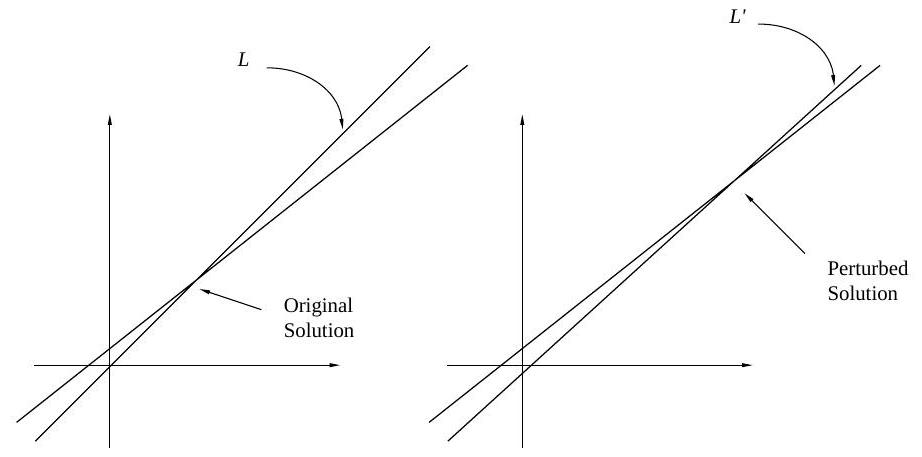

## *Ill-conditioned linear systems*

Meyer Ch 1.6

Consider $$
\begin{aligned}
& .835 x+.667 y=.168, \\
& .333 x+.266 y=.067,
\end{aligned}
$$

Exact solution:

$$
x=1 \quad \text { and } \quad y=-1 .
$$

But if we change just one digit…

$$
\begin{aligned}
& .835 x+.667 y=.168, \\
& .333 x+.266 y=.06\color{red}{6},
\end{aligned}
$$

Now exact solution:

$$
\hat{x}=-666 \quad \text { and } \quad \hat{y}=834
$$

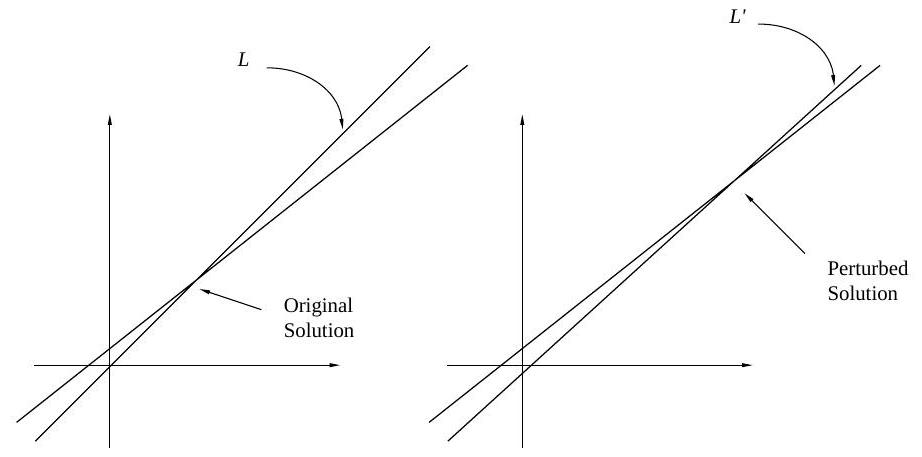

## *Measurement error () big changes in the exact solution*

What if $b_1$ and $b_2$ are the results of an experiment, need to be
read off a dial? Suppose:

-   dial can be read to tolerance of $\pm .001$,
-   values for $b_{1}$ and $b_{2}$ are read as .168 and .067,
    respectively. Then the exact solution is

$$
(x, y)=(1,-1) 
$$

-   But due to uncertainty, we have

$$
.167 \leq b_{1} \leq .169 \quad \text { and } \quad .066 \leq b_{2} \leq .068
$$

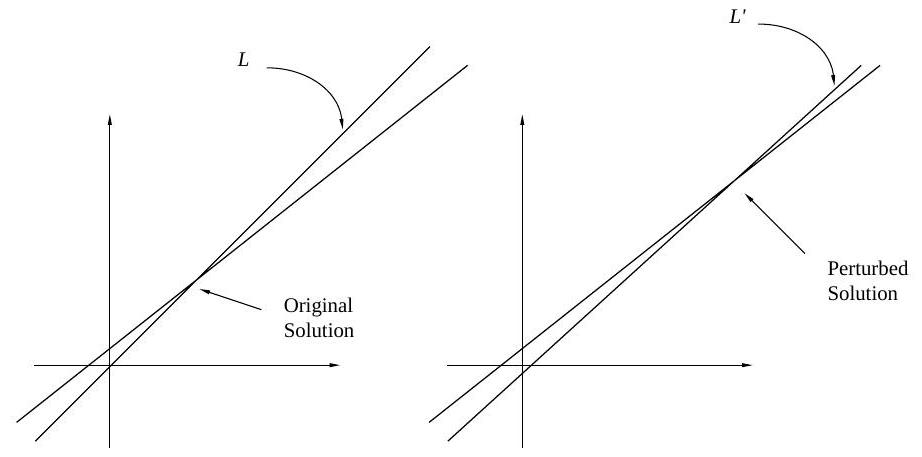

## *What range of solutions could we see?*

| $b_1$ | $b_2$ | $x$  | $y$   |
|-------|-------|------|-------|
| .168  | .067  | 1    | -1    |
| .167  | .068  | 934  | -1169 |
| .169  | .066  | -932 | 1169  |

Possible readings

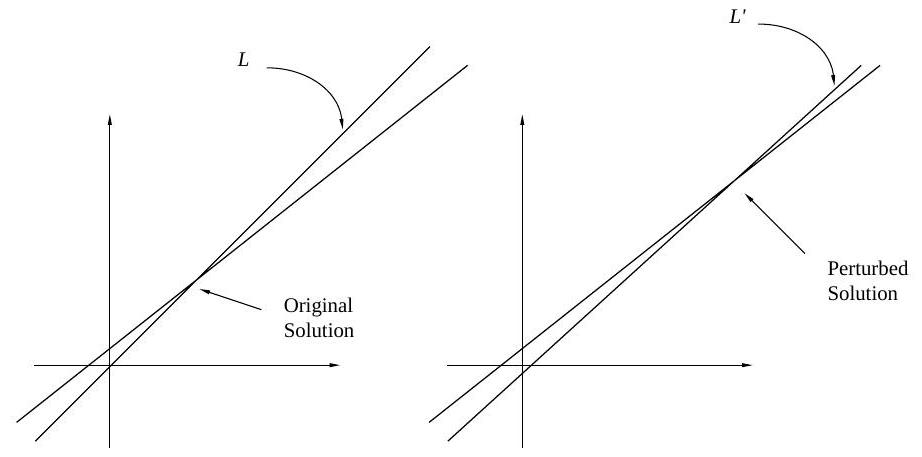

## *Geometrical interpretation*

If two straight lines are almost parallel and if one of the lines is
moved only slightly, then the point of intersection is drastically
altered.

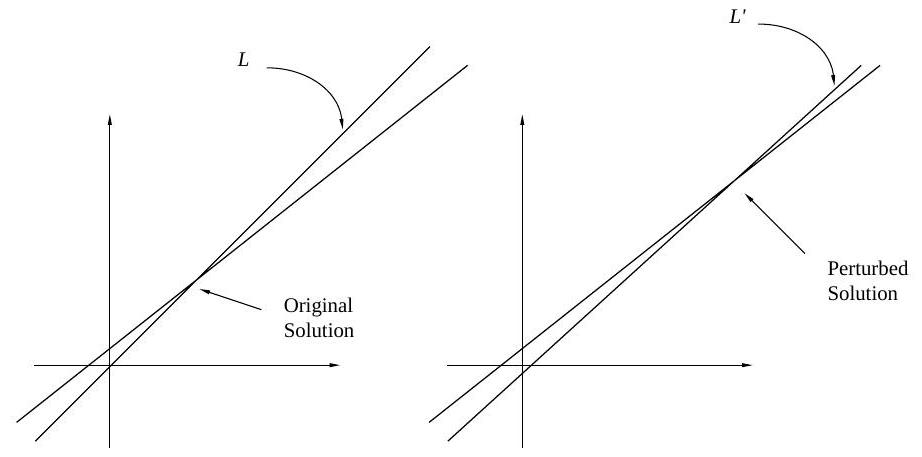

The point of intersection is the solution of the associated $2 \times 2$
linear system, so this is also drastically altered.


## *Takeaway: conditioning is about the *problem**

-   Often in real life, coefficients are empirically obtained
-   Will be off from “true” values by small amounts
-   For ill-conditioned systems, this means that solutions can be very
    far off from true solutions
-   We’ll cover techniques for quantifying conditioning, later in
    quarter
-   For now, can just try making small changes to some coefficients. Big
    changes in result? Ill-conditioned system!

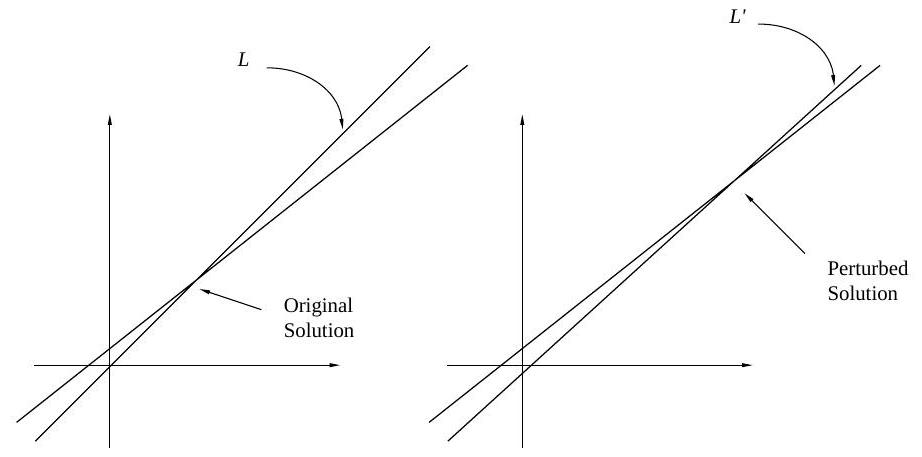

## *Bridge to the next example: interpolation can create ill-conditioned systems*

-   When we fit high-degree polynomials from data, we often build
    matrices (e.g. Vandermonde matrices) that can be numerically nasty.
-   Next: polynomial interpolation as a concrete “looks reasonable,
    behaves badly” example.

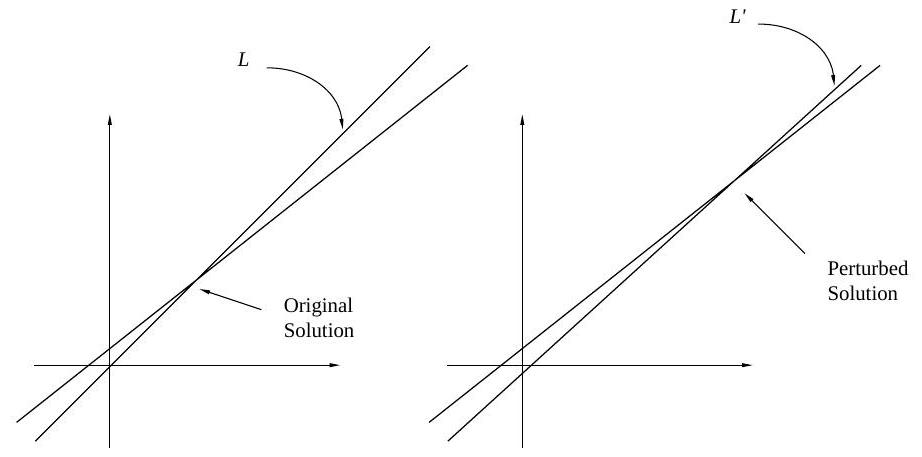

# *Example: Polynomial interpolation*

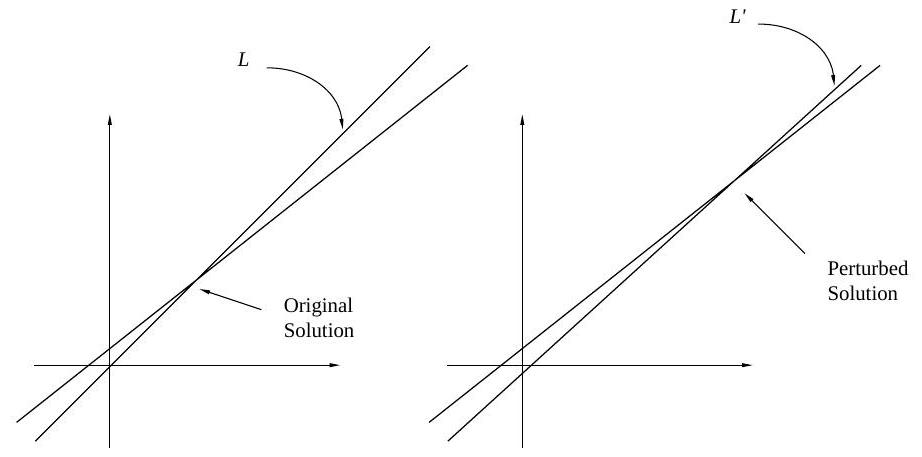

## *Polynomial interpolation*

https://colab.research.google.com/github/quantecon/lecture-julia.notebooks/blob/main/tools_and_techniques/iterative_methods_sparsity.ipynb#scrollTo=9aa1791b

Suppose we’d like to find a polynomial that can interpolate a given
function.

Take points 𝑥0,…𝑥𝑁 and values 𝑦0,…𝑦𝑁

Simple way: finding the coefficients \$ c_1, c_n \$ where

$$
P(x) = \sum_{i=0}^N c_i x^i
$$

. . .

This is a system of equations:

$$
\begin{array}
    cy_0 = c_0 + c_1 x_0 + \ldots c_N x_0^N\\
    \,\ldots\\
    \,y_N = c_0 + c_1 x_N + \ldots c_N x_N^N
\end{array}
$$

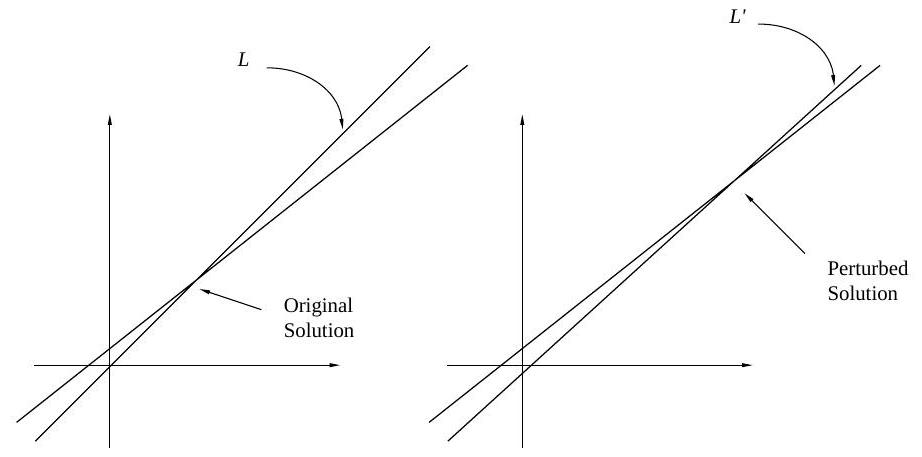

## *Polynomial interpolation*

Or, stacking, $c = \begin{bmatrix} c_0 & \ldots & c_N\end{bmatrix}$,
$y = \begin{bmatrix} y_0 & \ldots & y_N\end{bmatrix}$ , and

$$
A = \begin{bmatrix} 1 & x_0 & x_0^2 & \ldots &x_0^N\\
                    \vdots & \vdots & \vdots & \vdots & \vdots \\
                    1 & x_N & x_N^2 & \ldots & x_N^N
    \end{bmatrix}
$$

Let’s try solving this for a simple function, $y=exp(x)$.

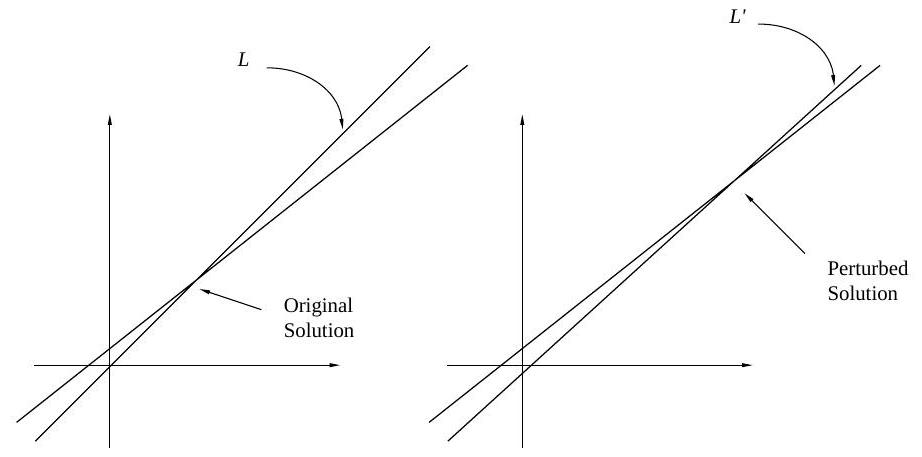

## *Polynomial interpolation*

$$
x*y
$$

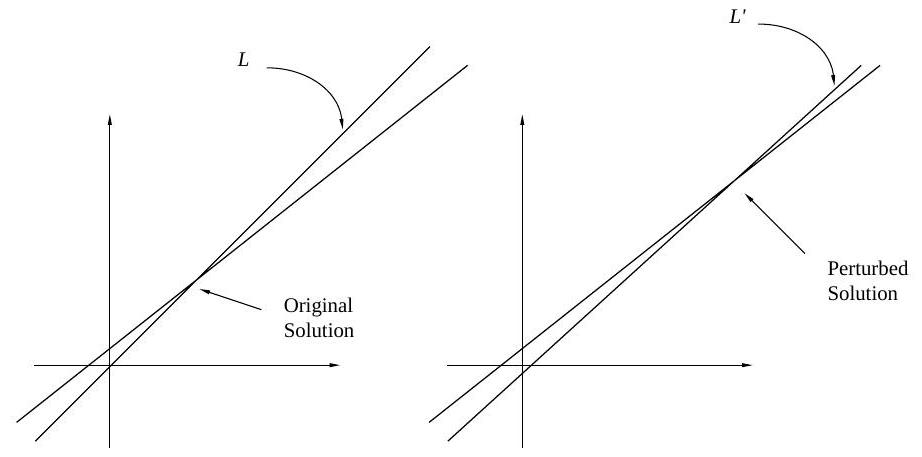

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# We are introducing a small error into b. Does it have a big impact on the x's we find?
def approx(n_points,jiggle=0):
  x = np.linspace(1,12,num=n_points)
  #xshuff = x+np.random.normal(size=n_points,scale=jiggle)
  y = np.exp(x)+np.exp(x/4)*np.random.normal(size=n_points,scale=jiggle)
  # Get matrix of exponents of x values => A
  n = len(x)
  A = np.zeros([n,n])
  for i in range(n):
    A[::,i] = np.power(x.T,i)
  b = y

  # Solve Ax=b linear eq. system to get 
  s = np.linalg.solve(A, b)
  # where x denotes coeffs of polynomial in reverse order
  # Flip polynomial coeffs
  s = np.flip(s,axis=0)
  # Print polynomial coeffs
  return s, x, y, A
s, x, y, A = approx(4)
# Evaluate polynomial at X axis and plot result

We’ll start with picking 4 interpolating points:
$\vec x = \mathtt{\text{[ 1.          4.66666667  8.33333333 12.        ]}}$.
Then we have our matrix A:

In [10]:
np.set_printoptions(suppress=True)

$$A = \begin{bmatrix} 1 & x_0 & x_0^2 & \ldots &x_0^N\\
                    \vdots & \vdots & \vdots & \vdots & \vdots \\
                    1 & x_N & x_N^2 & \ldots & x_N^N
    \end{bmatrix} = \left[\begin{matrix}1.0 & 1.0 & 1.0 & 1.0\\1.0 & 4.66666666666667 & 21.7777777777778 & 101.62962962963\\1.0 & 8.33333333333333 & 69.4444444444444 & 578.703703703703\\1.0 & 12.0 & 144.0 & 1728.0\end{matrix}\right] $$

Our $y$ values are
$\vec y = \mathtt{\text{[     2.71828183    106.3426754    4160.26200538 162754.791419  ]}}$.
We could solve this using Gauss-Jordan elimination, or here the solving
algorithm built into Numpy.

In [11]:
def make_plots(s, x, y, A):
  x_axis = np.linspace(np.min(x), np.max(x), num=5000)
  y_axis = np.polyval(s, x_axis)
  y_pred = np.polyval(s,x)
  plt.clf();
  plt.plot(x_axis, y_axis);
  plt.title("n = " + str(len(x)));
  plt.plot(x,y,'ro');
  plt.plot(x_axis,np.exp(x_axis));
  plt.show();
  
def error_norm(s,x,y,A):
    y_pred = np.polyval(s,x)
    return(np.linalg.norm(y_pred-np.exp(x),np.inf))

## *Results for n=4 and n=10 points*

``` python
_ = plt.figure(figsize=(6,6));
make_plots(*approx(4,jiggle=1000));
```

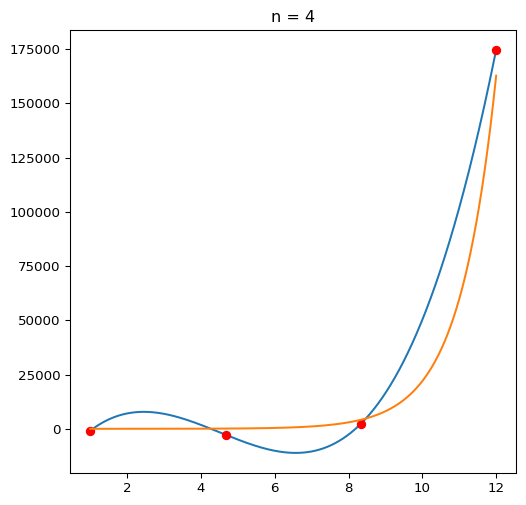

``` python
_ = plt.figure(figsize=(6,6));
make_plots(*approx(15,jiggle=1000));
```

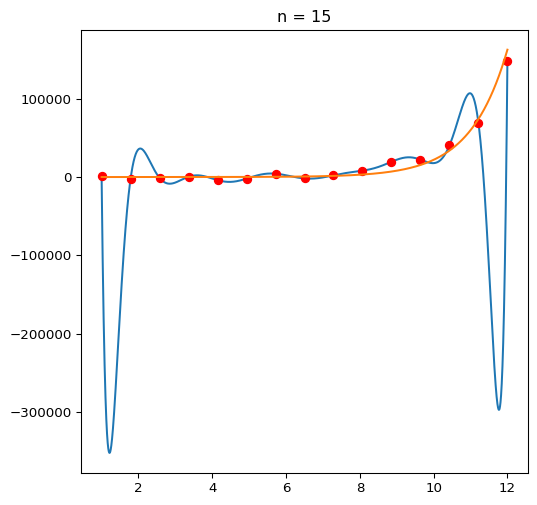

## *Max error for different values of n*

In [14]:
my_error = []
for i in range(1,21):
  my_error.append(error_norm(*approx(i)))

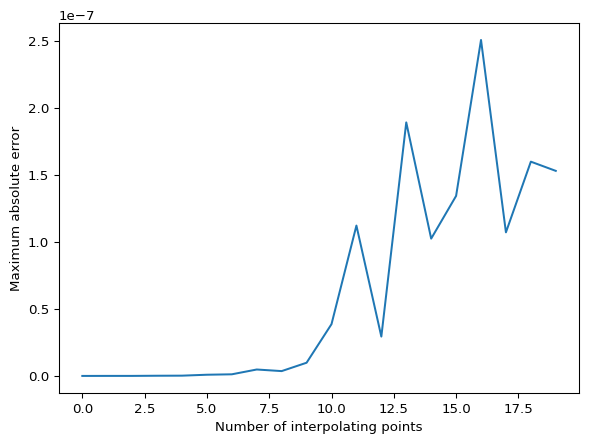

In [15]:
plt.clf()
plt.plot(my_error)
plt.xlabel("Number of interpolating points")
plt.ylabel("Maximum absolute error")
plt.show()

## *The problem: linear dependency*

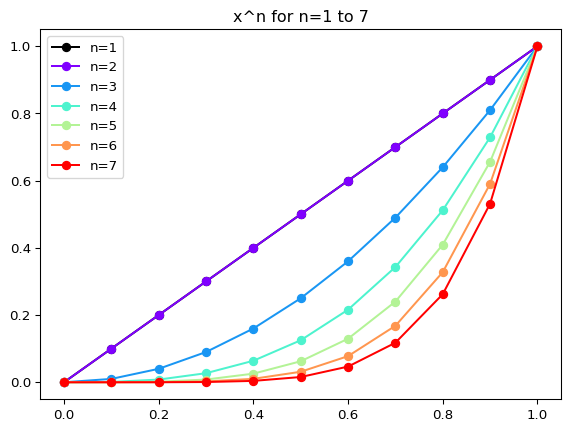

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 1.1, 0.1)
plt.plot(x, x, marker='o', linestyle='-', color='black', label='n=1')

colors = plt.cm.rainbow(np.linspace(0, 1, 6))

for i in range(1, 7):
  plt.plot(x, x**i, marker='o', linestyle='-', color=colors[i-1], label=f'n={i+1}')

plt.title("x^n for n=1 to 7")
plt.legend()
plt.show()

## *Wrap-up*

-   Gauss-Jordan elimination is a good *idea* (systematic row
    operations), but not always the best computational tool
-   Roundoff can turn “should be zero” into “is not zero”
-   Pivoting is a cheap way to make elimination behave much better
-   Ill-conditioning is different: sometimes the system itself is
    sensitive